In [6]:
from collections import Counter
from sklearn.metrics import f1_score
import numpy as np
from igng import IGNG
import pandas as pd
import matplotlib.pyplot as plt
import optuna

import torch
from collections import Counter

from torchvision import datasets
from torchvision import transforms

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
def evaluate_igng(model, X_train, y_train, X_test, y_test):

    model.partial_fit(X_train)

    train_nodes = model.predict(X_train)

    node_to_class = {}

    for node in set(train_nodes):

        labels = [
            y_train[i]
            for i, n in enumerate(train_nodes)
            if n == node
        ]

        node_to_class[node] = Counter(labels).most_common(1)[0][0]

    test_nodes = model.predict(X_test)

    y_pred = []

    for node in test_nodes:

        if node in node_to_class:
            y_pred.append(node_to_class[node])
        else:
            y_pred.append(-1)

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    n_nodes = len(model.nodes)

    return acc, prec, rec, f1, n_nodes

In [3]:
# ==========================================
# LOAD MNIST
# ==========================================

transform = transforms.ToTensor()

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

X = dataset.data.float() / 255.0
y = dataset.targets.numpy()

# flatten
X = X.view(len(X), -1).numpy()

# ==========================================
# TRAIN TEST
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

100%|██████████| 9.91M/9.91M [00:07<00:00, 1.38MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 331kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.82MB/s]


In [4]:
"""
# ==========================================
# DIFFERENT DATASET SIZES
# ==========================================

dataset_sizes = [
    1000,
    5000,
    10000,
    20000,
    40000
]

summary_results = []

# ==========================================
# LOOP OVER SIZES
# ==========================================

for size in dataset_sizes:

    print(f"\n===== SIZE = {size} =====")

    X_subset = X[:size]
    y_subset = y[:size]

    X_train, X_test, y_train, y_test = train_test_split(
        X_subset,
        y_subset,
        test_size=0.2,
        random_state=42,
        stratify=y_subset
    )

    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    # --------------------------------------
    # objective specific to this size
    # --------------------------------------

    def objective(trial):

        sigma = trial.suggest_float(
            "sigma",
            0.5,
            10.0,
            log=True
        )

        eps_b = trial.suggest_float(
            "eps_b",
            0.001,
            0.2,
            log=True
        )

        eps_n = trial.suggest_float(
            "eps_n",
            1e-4,
            0.05,
            log=True
        )

        age_max = trial.suggest_int(
            "age_max",
            10,
            200
        )

        mature_age = trial.suggest_int(
            "mature_age",
            2,
            20
        )

        max_nodes = trial.suggest_int(
            "max_nodes",
            20,
            500
        )

        model = IGNG(
            input_dim=X_train.shape[1],
            sigma=sigma,
            eps_b=eps_b,
            eps_n=eps_n,
            age_max=age_max,
            mature_age=mature_age,
            max_nodes=max_nodes
        )

        acc, prec, rec, f1, n_nodes = evaluate_igng(
            model,
            X_train,
            y_train,
            X_test,
            y_test
        )

        trial.set_user_attr(
            "accuracy",
            acc
        )

        trial.set_user_attr(
            "precision",
            prec
        )

        trial.set_user_attr(
            "recall",
            rec
        )

        trial.set_user_attr(
            "f1",
            f1
        )

        trial.set_user_attr(
            "nodes",
            n_nodes
        )

        return f1

    # --------------------------------------
    # run optuna
    # --------------------------------------

    study = optuna.create_study(
        direction="maximize",
        study_name=f"IGNG_MNIST_{size}"
    )

    study.optimize(
        objective,
        n_trials=50
    )

    # --------------------------------------
    # save all trials
    # --------------------------------------

    trials_df = study.trials_dataframe()

    trials_df.to_csv(
        f"igng_trials_{size}.csv",
        index=False
    )

    # --------------------------------------
    # save best result
    # --------------------------------------

    best_trial = study.best_trial

    summary_results.append({

        "dataset_size": size,

        "best_f1":
            best_trial.user_attrs["f1"],

        "best_accuracy":
            best_trial.user_attrs["accuracy"],

        "best_precision":
            best_trial.user_attrs["precision"],

        "best_recall":
            best_trial.user_attrs["recall"],

        "nodes":
            best_trial.user_attrs["nodes"],

        **best_trial.params
    })

# ==========================================
# GLOBAL SUMMARY
# ==========================================

summary_df = pd.DataFrame(
    summary_results
)

summary_df.to_csv(
    "igng_mnist_summary.csv",
    index=False
)

print(summary_df)
"""

'\n# ==========================================\n# DIFFERENT DATASET SIZES\n# ==========================================\n\ndataset_sizes = [\n    1000,\n    5000,\n    10000,\n    20000,\n    40000\n]\n\nsummary_results = []\n\n# ==========================================\n# LOOP OVER SIZES\n# ==========================================\n\nfor size in dataset_sizes:\n\n    print(f"\n===== SIZE = {size} =====")\n\n    X_subset = X[:size]\n    y_subset = y[:size]\n\n    X_train, X_test, y_train, y_test = train_test_split(\n        X_subset,\n        y_subset,\n        test_size=0.2,\n        random_state=42,\n        stratify=y_subset\n    )\n\n    X_train = torch.tensor(\n        X_train,\n        dtype=torch.float32\n    )\n\n    X_test = torch.tensor(\n        X_test,\n        dtype=torch.float32\n    )\n\n    # --------------------------------------\n    # objective specific to this size\n    # --------------------------------------\n\n    def objective(trial):\n\n        sigma = tri

    size   mean_f1    std_f1   best_f1  mean_nodes  best_nodes
0   1000  0.782810  0.161364  0.884104      295.06         444
4   5000  0.794680  0.121878  0.860523      324.36         416
1  10000  0.772746  0.137467  0.855949      362.46         499
2  20000  0.753377  0.154068  0.837445      370.46         500
3  40000  0.771267  0.128687  0.848852      379.76         494


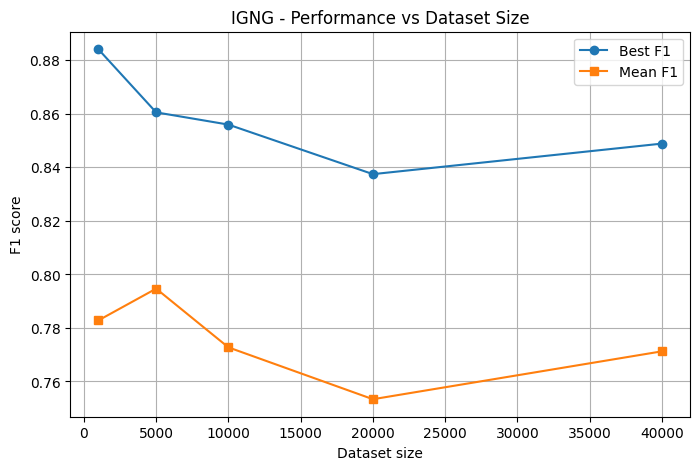

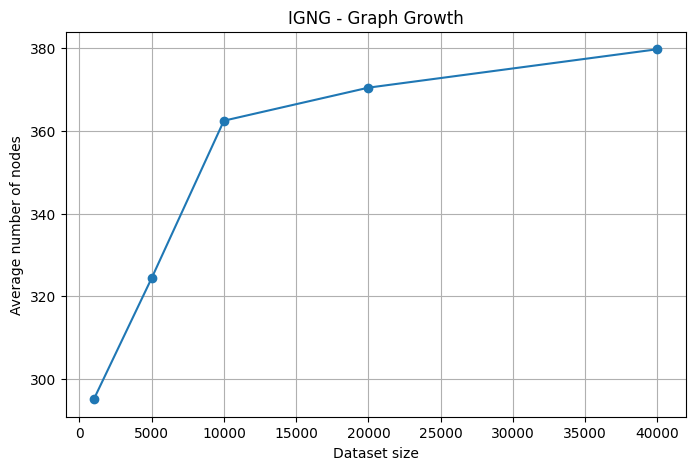

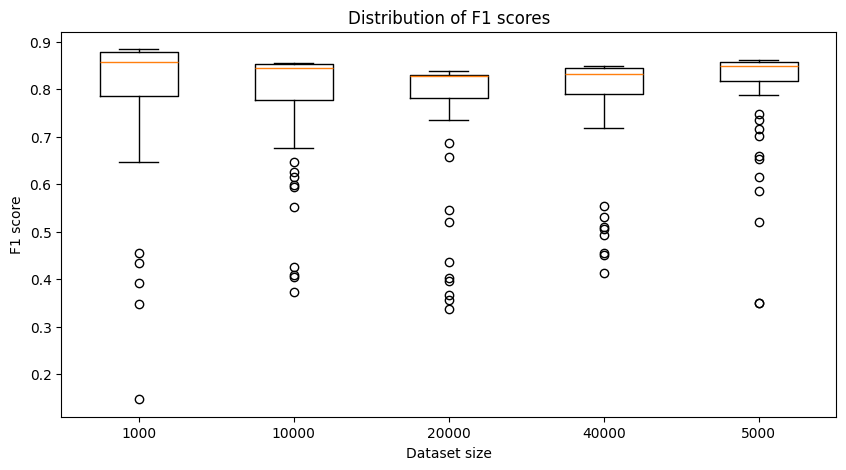

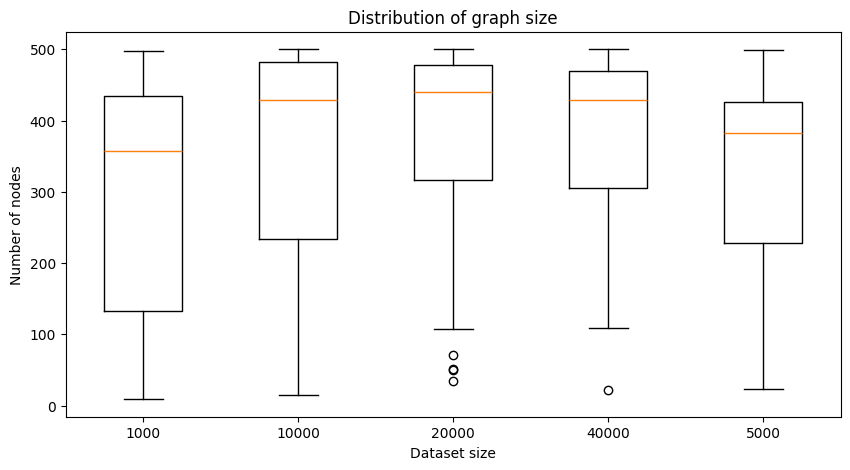


Correlation with F1:

value                   1.000000
user_attrs_f1           1.000000
user_attrs_accuracy     0.998923
user_attrs_recall       0.998923
user_attrs_precision    0.997745
user_attrs_nodes        0.722051
params_max_nodes        0.422488
number                  0.309543
params_eps_b            0.212939
params_eps_n            0.099667
params_mature_age      -0.181476
params_age_max         -0.188587
params_sigma           -0.559669
Name: user_attrs_f1, dtype: float64


In [ ]:
from pathlib import Path

# ==========================================
# CHARGEMENT
# ==========================================

files = sorted(Path("./data").glob("igng_trials_*.csv"))

results = []

for file in files:

    size = int(file.stem.split("_")[-1])

    df = pd.read_csv(file)

    results.append({
        "size": size,
        "mean_f1": df["user_attrs_f1"].mean(),
        "std_f1": df["user_attrs_f1"].std(),
        "best_f1": df["user_attrs_f1"].max(),
        "mean_nodes": df["user_attrs_nodes"].mean(),
        "best_nodes": df.loc[
            df["user_attrs_f1"].idxmax(),
            "user_attrs_nodes"
        ]
    })

summary = pd.DataFrame(results)

summary = summary.sort_values("size")

print(summary)

summary.to_csv(
    "summary_stats.csv",
    index=False
)

# ==========================================
# F1 VS DATASET SIZE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    summary["size"],
    summary["best_f1"],
    marker="o",
    label="Best F1"
)

plt.plot(
    summary["size"],
    summary["mean_f1"],
    marker="s",
    label="Mean F1"
)

plt.xlabel("Dataset size")
plt.ylabel("F1 score")
plt.title("IGNG - Performance vs Dataset Size")
plt.grid(True)
plt.legend()

plt.savefig(
    "f1_vs_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# NODES VS DATASET SIZE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    summary["size"],
    summary["mean_nodes"],
    marker="o"
)

plt.xlabel("Dataset size")
plt.ylabel("Average number of nodes")
plt.title("IGNG - Graph Growth")
plt.grid(True)

plt.savefig(
    "nodes_vs_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# BOXPLOT DES F1
# ==========================================

data = []

labels = []

for file in files:

    size = int(file.stem.split("_")[-1])

    df = pd.read_csv(file)

    data.append(df["user_attrs_f1"])

    labels.append(str(size))

plt.figure(figsize=(10,5))

plt.boxplot(
    data,
    tick_labels=labels
)

plt.xlabel("Dataset size")
plt.ylabel("F1 score")
plt.title("Distribution of F1 scores")

plt.savefig(
    "boxplot_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# BOXPLOT NODES
# ==========================================

data = []

for file in files:

    df = pd.read_csv(file)

    data.append(df["user_attrs_nodes"])

plt.figure(figsize=(10,5))

plt.boxplot(
    data,
    tick_labels=labels
)

plt.xlabel("Dataset size")
plt.ylabel("Number of nodes")
plt.title("Distribution of graph size")

plt.savefig(
    "boxplot_nodes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# CORRELATION
# ==========================================

all_trials = []

for file in files:

    df = pd.read_csv(file)

    all_trials.append(df)

all_trials = pd.concat(
    all_trials,
    ignore_index=True
)

corr = all_trials.corr(
    numeric_only=True
)

print("\nCorrelation with F1:\n")

print(
    corr["user_attrs_f1"]
    .sort_values(
        ascending=False
    )
)

    size  mean_accuracy  std_accuracy  best_accuracy  mean_nodes  best_nodes
0   1000       0.786800      0.154139       0.885000      295.06         444
4   5000       0.799980      0.111462       0.862000      324.36         421
1  10000       0.776970      0.131668       0.857000      362.46         499
2  20000       0.756990      0.150194       0.838500      370.46         500
3  40000       0.774797      0.124054       0.849625      379.76         494


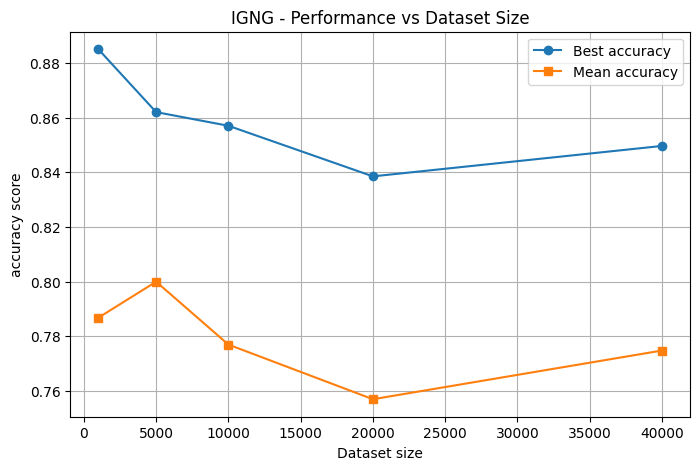

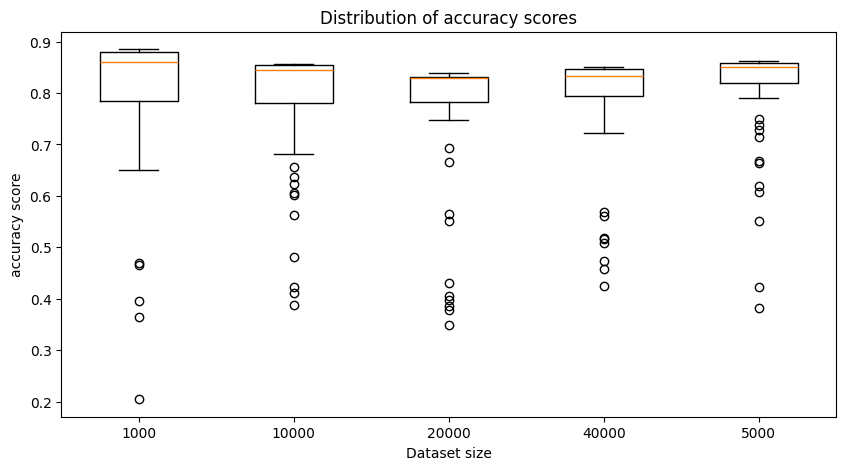


Correlation with accuracy:

user_attrs_accuracy     1.000000
user_attrs_recall       1.000000
user_attrs_f1           0.998923
value                   0.998923
user_attrs_precision    0.995694
user_attrs_nodes        0.718967
params_max_nodes        0.418299
number                  0.315955
params_eps_b            0.214621
params_eps_n            0.102849
params_mature_age      -0.183425
params_age_max         -0.190640
params_sigma           -0.549254
Name: user_attrs_accuracy, dtype: float64


In [9]:
results = []

for file in files:

    size = int(file.stem.split("_")[-1])

    df = pd.read_csv(file)

    results.append({
        "size": size,
        "mean_accuracy": df["user_attrs_accuracy"].mean(),
        "std_accuracy": df["user_attrs_accuracy"].std(),
        "best_accuracy": df["user_attrs_accuracy"].max(),
        "mean_nodes": df["user_attrs_nodes"].mean(),
        "best_nodes": df.loc[
            df["user_attrs_accuracy"].idxmax(),
            "user_attrs_nodes"
        ]
    })

summary = pd.DataFrame(results)

summary = summary.sort_values("size")

print(summary)

summary.to_csv(
    "summary_stats.csv",
    index=False
)

# ==========================================
# accuracy VS DATASET SIZE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    summary["size"],
    summary["best_accuracy"],
    marker="o",
    label="Best accuracy"
)

plt.plot(
    summary["size"],
    summary["mean_accuracy"],
    marker="s",
    label="Mean accuracy"
)

plt.xlabel("Dataset size")
plt.ylabel("accuracy score")
plt.title("IGNG - Performance vs Dataset Size")
plt.grid(True)
plt.legend()

plt.savefig(
    "accuracy_vs_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# BOXPLOT DES accuracy
# ==========================================

data = []

labels = []

for file in files:

    size = int(file.stem.split("_")[-1])

    df = pd.read_csv(file)

    data.append(df["user_attrs_accuracy"])

    labels.append(str(size))

plt.figure(figsize=(10,5))

plt.boxplot(
    data,
    tick_labels=labels
)

plt.xlabel("Dataset size")
plt.ylabel("accuracy score")
plt.title("Distribution of accuracy scores")

plt.savefig(
    "boxplot_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# CORRELATION
# ==========================================

all_trials = []

for file in files:

    df = pd.read_csv(file)

    all_trials.append(df)

all_trials = pd.concat(
    all_trials,
    ignore_index=True
)

corr = all_trials.corr(
    numeric_only=True
)

print("\nCorrelation with accuracy:\n")

print(
    corr["user_attrs_accuracy"]
    .sort_values(
        ascending=False
    )
)

In [20]:
import pandas as pd

df = pd.read_csv("data/igng_trials_40000.csv")

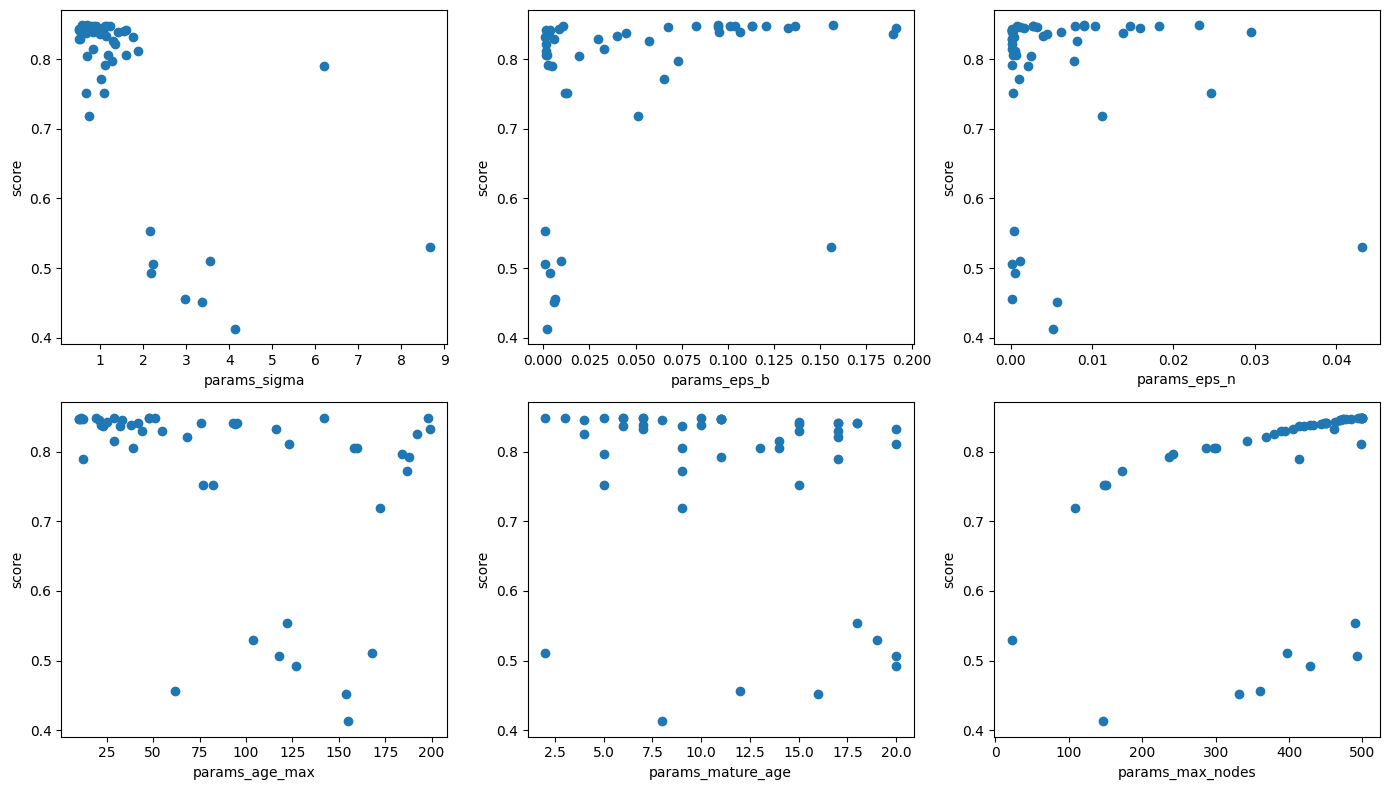

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    2,
    3,
    figsize=(14,8)
)

params = [
    "params_sigma",
    "params_eps_b",
    "params_eps_n",
    "params_age_max",
    "params_mature_age",
    "params_max_nodes"
]

for ax, p in zip(axs.ravel(), params):

    ax.scatter(
        df[p],
        df["value"]
    )

    ax.set_xlabel(p)
    ax.set_ylabel("score")

plt.tight_layout()
plt.show()

params_sigma         0.851260
params_age_max       0.077075
params_max_nodes     0.055469
params_mature_age    0.007920
params_eps_b         0.005709
params_eps_n         0.002568
dtype: float64


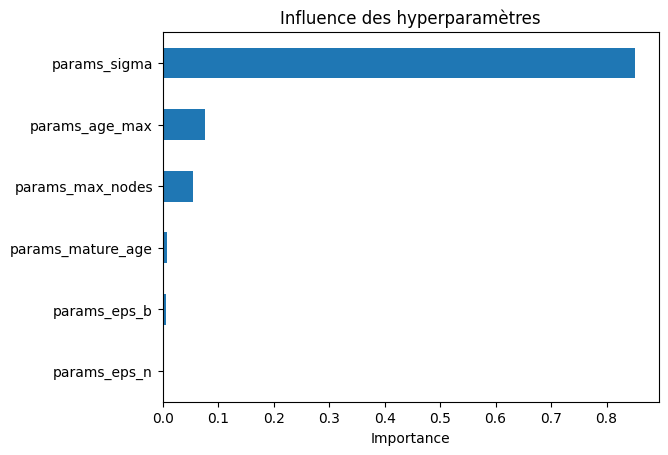

In [22]:
from sklearn.ensemble import RandomForestRegressor

X = df[
    [
        "params_sigma",
        "params_eps_b",
        "params_eps_n",
        "params_age_max",
        "params_mature_age",
        "params_max_nodes"
    ]
]

y = df["value"]

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

importance.sort_values().plot.barh()

plt.xlabel("Importance")
plt.title("Influence des hyperparamètres")
plt.show()

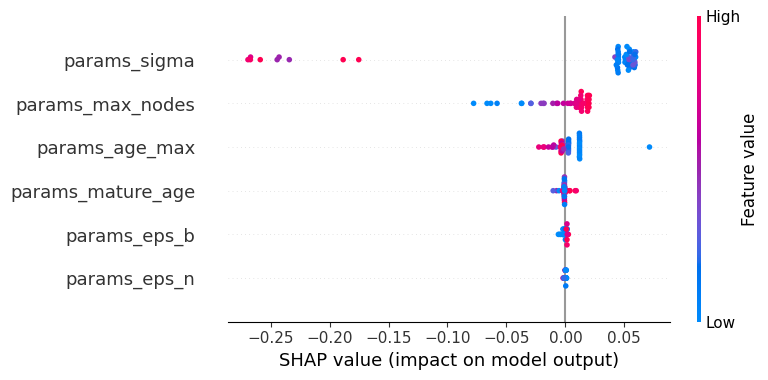

In [23]:
import shap

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X, y)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X
)